In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
data = load_wine(as_frame = True)

X = data.data
y = data.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 22)

In [4]:
model = DecisionTreeClassifier(random_state = 22)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,22
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [5]:
y_pred = model.predict(X_test)

In [6]:
print("Train data accuracy: ", accuracy_score(y_true = y_train, y_pred = model.predict(X_train)))
print("Test data accuracy: ", accuracy_score(y_true = y_test, y_pred = y_pred))

Train data accuracy:  1.0
Test data accuracy:  0.8222222222222222


In [7]:
from sklearn.ensemble import BaggingClassifier

In [8]:
estimator_range = [2,4,6,8,10,12,14,16] 

In [9]:
models = []
scores = []

for n_estimators in estimator_range:
    clf = BaggingClassifier(n_estimators = n_estimators, random_state = 22)
    clf.fit(X_train, y_train)
    models.append(clf)
    scores.append(accuracy_score(y_true = y_test, y_pred = clf.predict(X_test)))

In [10]:
import matplotlib.pyplot as plt

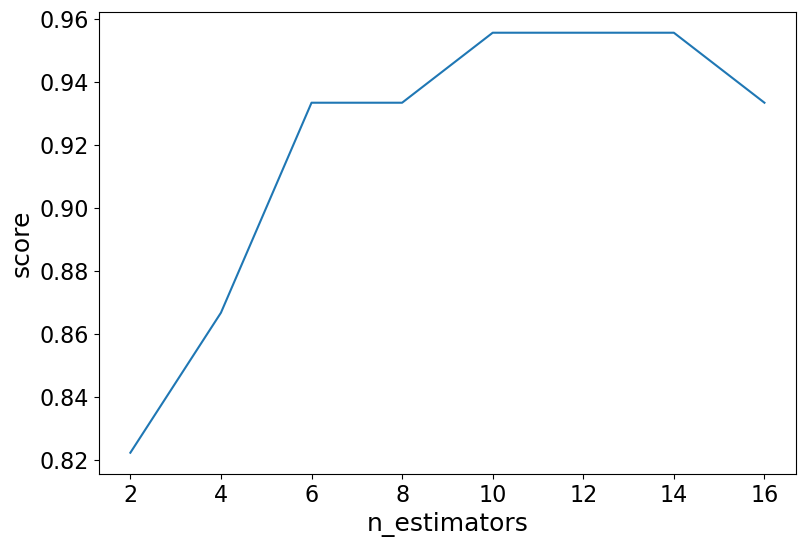

In [11]:
plt.figure(figsize=(9, 6))
plt.plot(estimator_range, scores)

plt.xlabel("n_estimators", fontsize = 18)
plt.ylabel("score", fontsize = 18)
plt.tick_params(labelsize = 16)

plt.show()

In [14]:
oob_model = BaggingClassifier(n_estimators = 12, oob_score = True, random_state = 22)

oob_model.fit(X_train, y_train)

print(oob_model.oob_score_)

0.9398496240601504
